In [34]:
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
games = pd.read_csv('games.csv')

In [36]:
games.columns

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer',
       'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score',
       'user_score', 'critic_review_count', 'user_review_count',
       'na_sales_million', 'eu_sales_million', 'jp_sales_million',
       'other_sales_million', 'global_sales_million',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs'],
      dtype='object')

In [37]:
games['year'] = pd.to_datetime(games['year'], format = "%Y")
games['year'] = games['year'].dt.year

In [38]:
games['publisher_region'].unique()

array(['Poland', 'France', 'USA', 'Japan', 'UK', 'Finland', 'Germany',
       'Italy', 'Denmark', 'Belgium', 'Various', 'Canada', 'Austria',
       'Sweden', 'Spain'], dtype=object)

# Publisher wise global sales rvenue

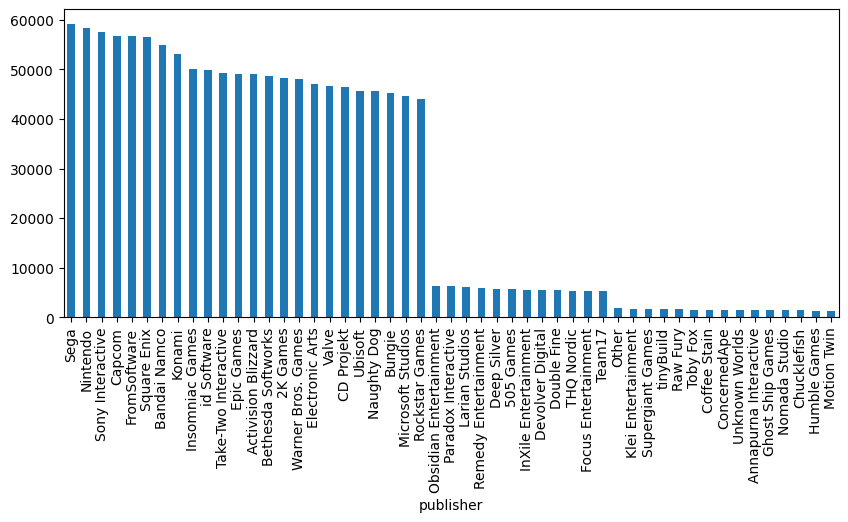

In [39]:
data = games.groupby('publisher')['global_sales_million'].sum().sort_values(ascending = False)
ax = data.plot(kind = 'bar', figsize= (10, 4))


Revenue within the gaming industry is highly concentrated among a small number of publishers, indicating strong brand recognition, established franchises, and larger market reach. Smaller publishers may need differentiated content or niche strategies to compete effectively

# Genre wise sales share

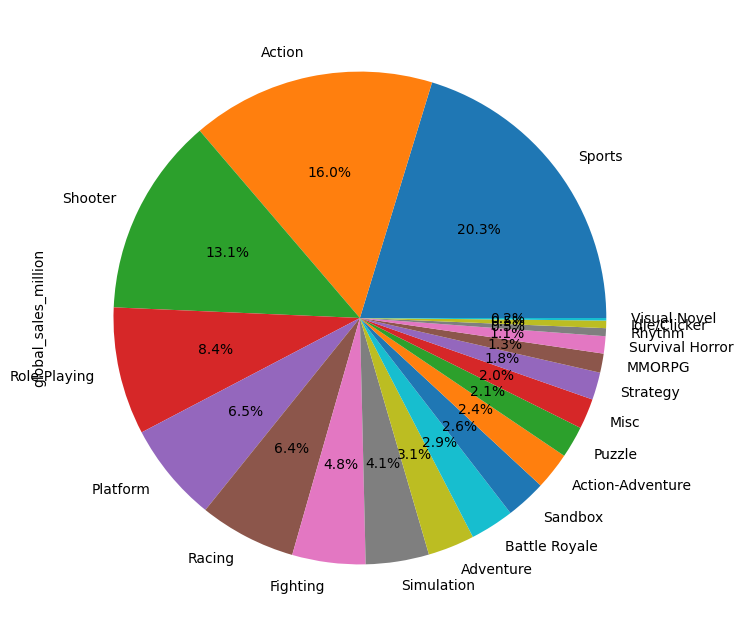

In [43]:
data = games.groupby('genre')['global_sales_million'].sum().sort_values(ascending = False)
ax = data.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))

Sports, Action, and Shooter genres represent the largest revenue-generating segments of the market. Studios seeking maximum commercial potential may prioritize investment in these genres due to their broad consumer appeal.

# Platform type sales revenue

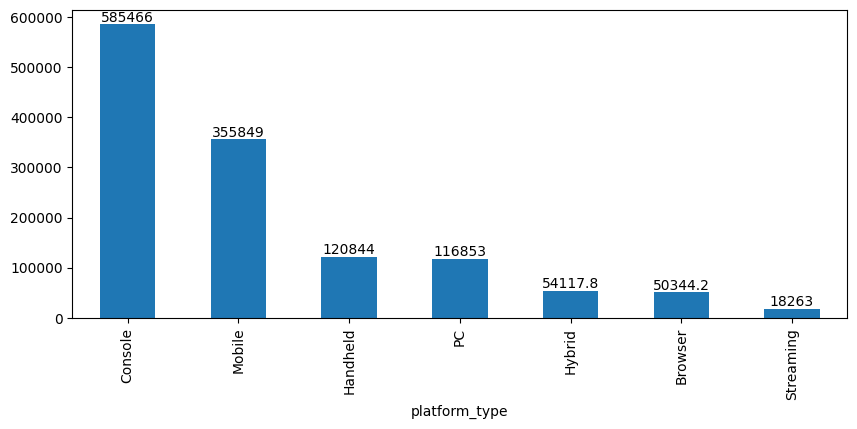

In [44]:
data = games.groupby('platform_type')['global_sales_million'].sum().sort_values(ascending = False)
ax = data.plot(kind = 'bar', figsize= (10, 4))
ax.bar_label(ax.containers[0])

plt.show()

Console and mobile platforms dominate industry sales, highlighting where consumer demand is strongest. Developers can maximize market reach by prioritizing releases on these platforms.

# Publisher countries revenue

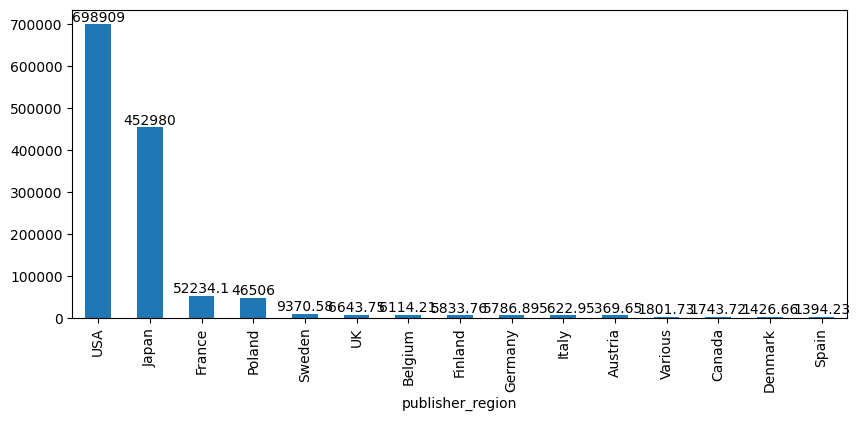

In [45]:
data = games.groupby('publisher_region')['global_sales_million'].sum().sort_values(ascending = False)
ax = data.plot(kind = 'bar', figsize= (10, 4))
ax.bar_label(ax.containers[0])

plt.show()

The video game publishing landscape is heavily influenced by companies headquartered in the United States and Japan, reflecting their long-standing leadership in game development, publishing infrastructure, and global distribution networks.

# Region wise sales

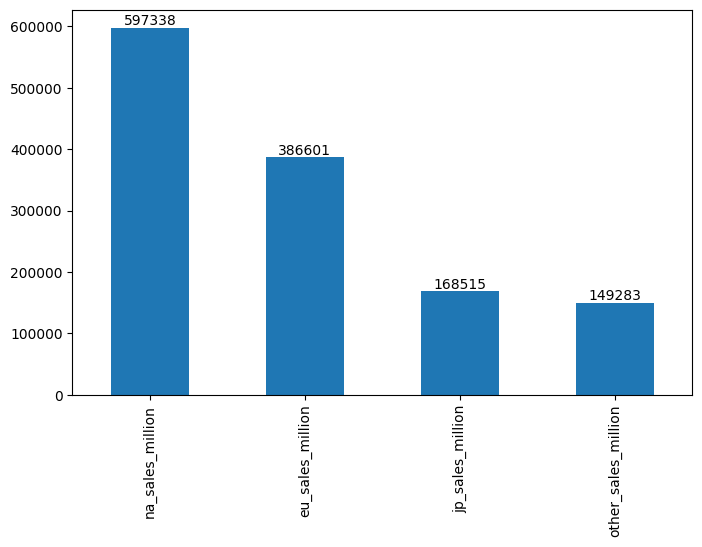

In [46]:
df = games[['na_sales_million', 'eu_sales_million', 'jp_sales_million','other_sales_million']].sum().sort_values(ascending = False)
ax = df.plot(kind='bar', figsize=(8, 5))
ax.bar_label(ax.containers[0])
plt.show()

North America and Europe remain the largest consumer markets for video games, suggesting that localization, marketing campaigns, and distribution efforts in these regions can have the greatest impact on revenue growth.

# Year wise revenue trend

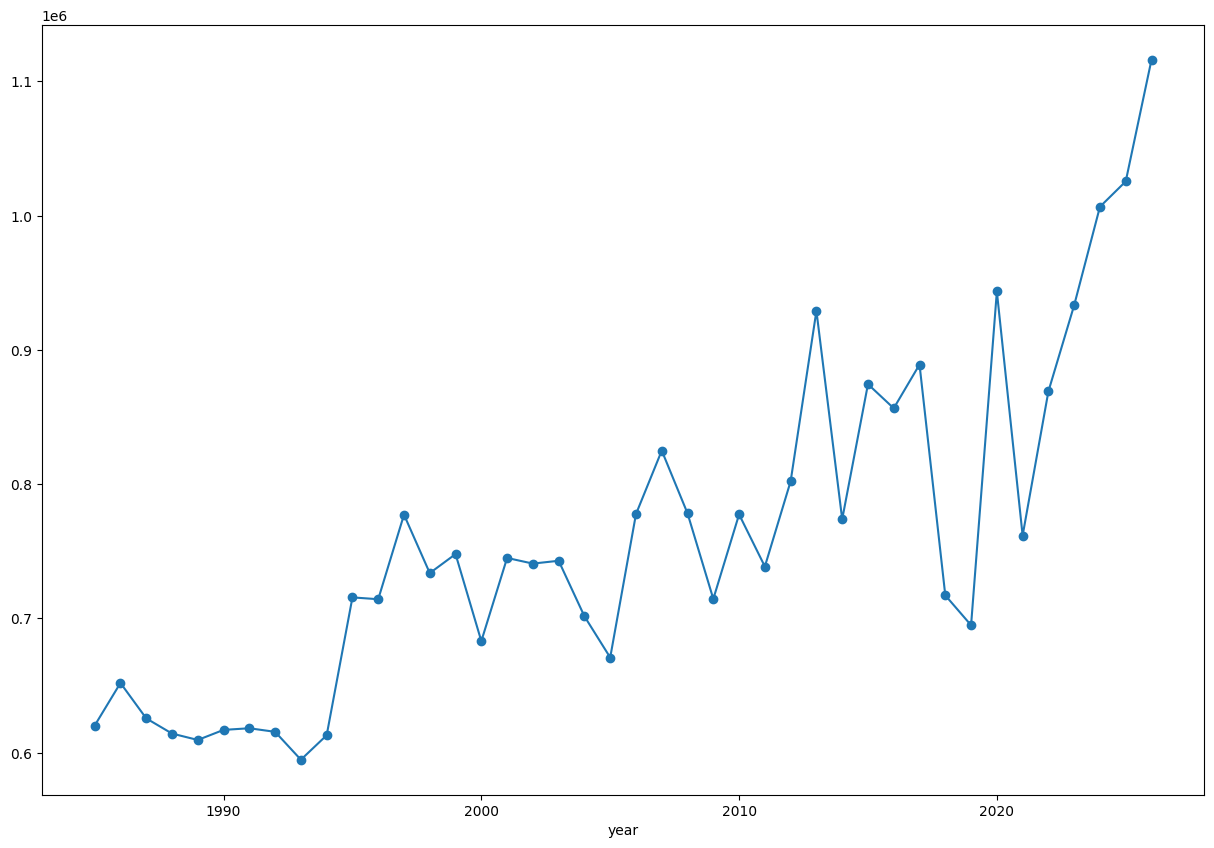

In [47]:
df = games.groupby('year')['estimated_revenue_million_usd'].sum()

ax = df.plot(kind='line', figsize=(15, 10), marker='o')

plt.show()

The long-term upward trend in industry revenue indicates sustained growth in gaming adoption, supported by technological advancements, digital distribution, online gaming, and expanding player demographics.

# Average Sales by Genre

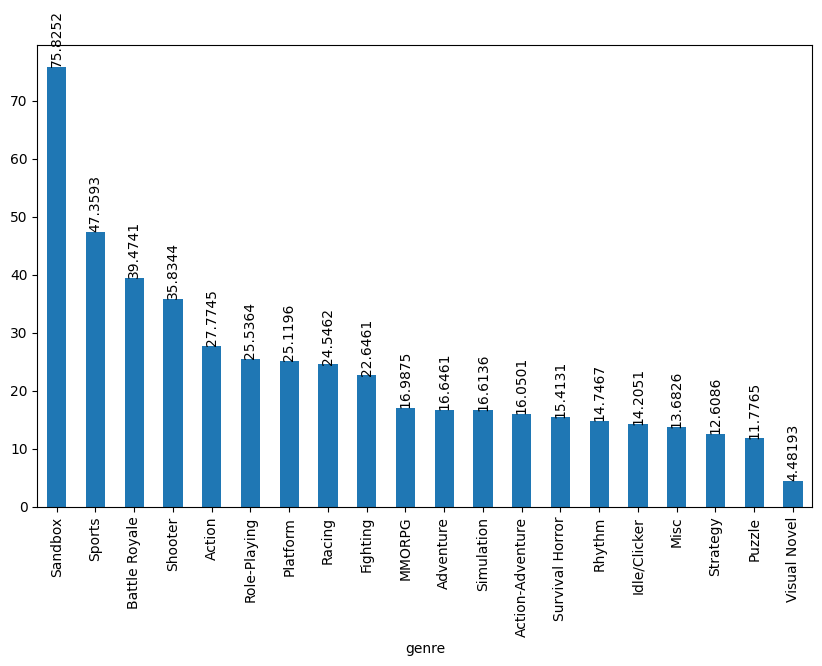

In [48]:
data = games.groupby('genre')['global_sales_million'].mean().sort_values(ascending = False)
ax = data.plot(kind='bar',figsize=(10, 6))
ax.bar_label(ax.containers[0], rotation=90)
plt.show()

Revenue performance varies considerably across genres, suggesting that genre selection plays a critical role in commercial success. Understanding genre-level demand can improve investment and portfolio planning decisions.

# Publisher Tier Sales

[Text(0, 0, '34.2237'), Text(0, 0, '7.87118'), Text(0, 0, '3.82062')]

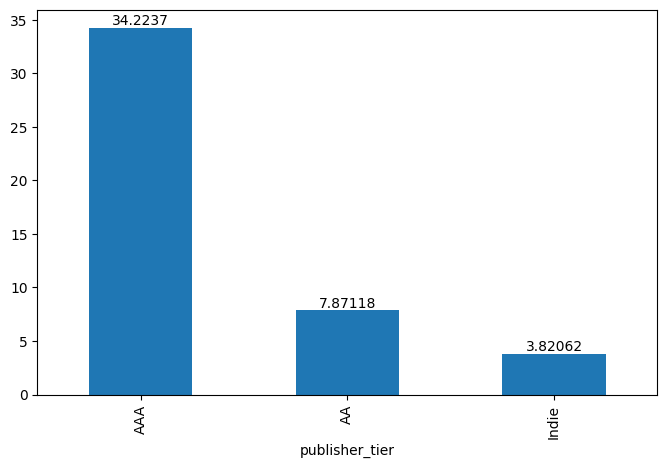

In [49]:
df = games.groupby('publisher_tier')['global_sales_million'].mean().sort_values(ascending = False)
ax = df.plot(kind = 'bar', figsize = (8, 5))
ax.bar_label(ax.containers[0])

Games released by top-tier publishers tend to achieve stronger commercial performance, likely due to larger marketing budgets, stronger intellectual property portfolios, and wider distribution capabilities

# Do Reviews and Ratings Impact Sales?

In [50]:
cols = ['user_score', 'critic_review_count', 'user_review_count', 'global_sales_million']

games[cols].corr()

,user_score,critic_review_count,user_review_count,global_sales_million
user_score,1.000000,0.003557,0.046792,0.157384
critic_review_count,0.003557,1.000000,-0.001134,-0.006465
user_review_count,0.046792,-0.001134,1.000000,0.010680
global_sales_million,0.157384,-0.006465,0.010680,1.000000


Weak correlations between review metrics and sales suggest that commercial success is influenced by additional factors such as franchise popularity, marketing effectiveness, platform availability, and release timing.

# Do Sequels Sell Better?

In [51]:
games.groupby('is_sequel')['global_sales_million'].mean()

is_sequel
0    20.756015
1    33.565341
Name: global_sales_million, dtype: float64

Established franchises provide a significant commercial advantage, as sequels benefit from existing brand awareness and customer loyalty, reducing market uncertainty compared to launching entirely new intellectual property.

# Do Multiplayer Games Sell Better?

In [52]:
games.groupby('online_multiplayer')['global_sales_million'].mean()

online_multiplayer
0    21.721085
1    30.229948
Name: global_sales_million, dtype: float64

Multiplayer functionality appears to enhance commercial performance by increasing player engagement, encouraging social interaction, and extending product lifespan through recurring player activity.

# Do GOTY-Nominated Games Perform Better?

In [53]:
games.groupby('goty_nominated')['global_sales_million'].mean()

goty_nominated
0    24.991524
1    48.361013
Name: global_sales_million, dtype: float64

Industry recognition is associated with stronger commercial performance, suggesting that high-quality game design and critical acclaim can positively influence consumer purchasing decisions.

# Do Award-Winning Games Perform Better?

In [54]:
games.groupby('goty_won')['global_sales_million'].mean()

goty_won
0    25.898161
1    46.101834
Name: global_sales_million, dtype: float64

Award-winning titles demonstrate stronger market performance, indicating that exceptional quality and industry recognition contribute to increased visibility and consumer trust.

# Top-Rated Genres

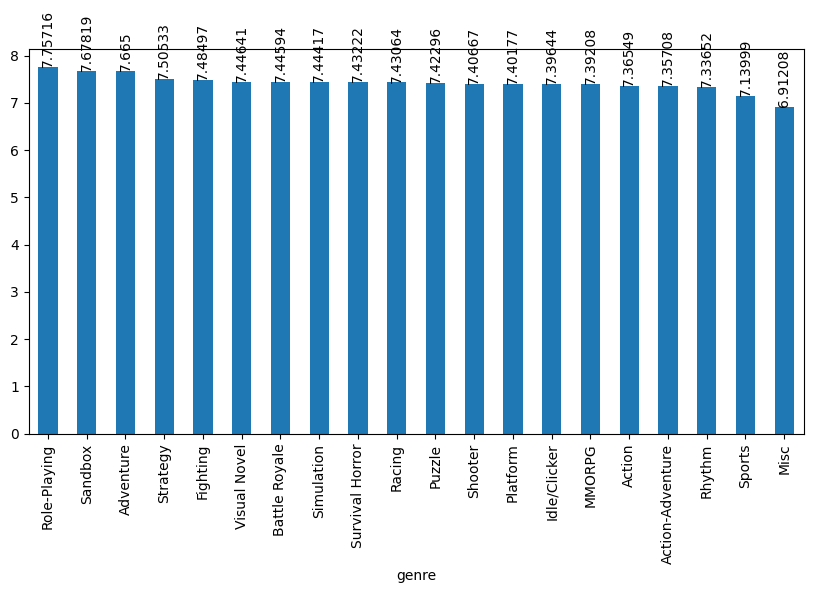

In [55]:
df = games.groupby('genre')['user_score'].mean().sort_values(ascending=False)
ax = df.plot(kind = 'bar', figsize=(10, 5))
ax.bar_label(ax.containers[0], rotation = 90)
plt.show()

While some genres may not generate the highest sales, they achieve superior player satisfaction levels, highlighting opportunities to build long-term brand loyalty and community engagement

# Do highly rated games sell more?

C:\Users\PAVANA HEBBAR\AppData\Local\Temp\ipykernel_660\522934730.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = games.groupby('score_bucket')['global_sales_million'].mean().sort_values(ascending  = False).plot(kind = 'bar', figsize = (8, 5))


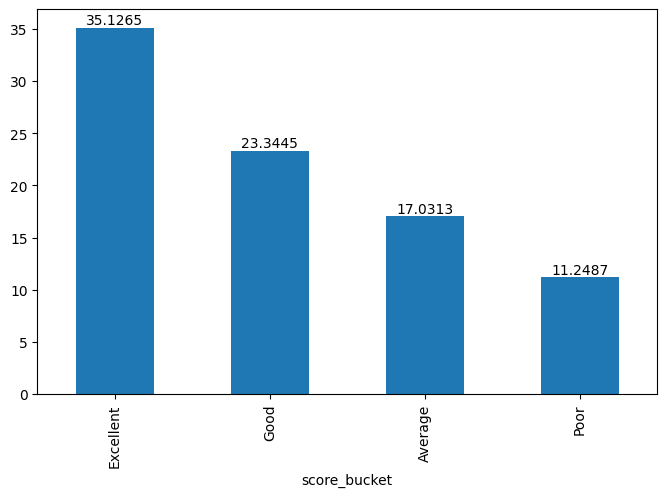

In [56]:
games['score_bucket'] = pd.cut(
    games['user_score'],
    bins=[0, 4, 6, 8, 10],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)

ax = games.groupby('score_bucket')['global_sales_million'].mean().sort_values(ascending  = False).plot(kind = 'bar', figsize = (8, 5))
ax.bar_label(ax.containers[0])
plt.show()

Higher player satisfaction is associated with stronger commercial performance, suggesting that investments in gameplay quality and user experience can positively influence sales outcomes.

# Which games attracted attention but disappointed players?

In [57]:
top_games =  games.sort_values(['user_review_count', 'user_score'], ascending=[False, True])['title'].head(10).tolist()
for i in top_games:
    print(i)

Overwatch 5
Stardew Odyssey
Gold Alert 2
Batman: Arkham City
Rainbow Six: Frontier
TrackMania Saga
StarCraft 3
FIFA 2026
Devil May Cry
Rayman Genesis


These titles generated substantial consumer interest but failed to meet player expectations, indicating potential issues related to product quality, launch execution, or marketing-to-product alignment.

# Hidden Gems

In [72]:
df = games[(games['user_score'] > 8.5) & (games['global_sales_million'] < games['global_sales_million'].median())]
df['title']

18                 Night in the Saga
19                       Injustice 2
59       Final Fantasy XIV: New Dawn
62                   Stardew Genesis
83                      Until Dawn 3
                    ...             
49926          King of Fighters 2024
49941              Kirby's Awakening
49959               Cities: New Dawn
49963              TrackMania Empire
49979                Shadow of Realm
Name: title, Length: 2859, dtype: object

# What game characteristics associated with more revenue

In [69]:
features = ['is_sequel', 'online_multiplayer', 'goty_nominated', 'goty_won', 'dlc_released', 'microtransactions']

result = []

for col in features:
    avg_no = games.groupby(col)['global_sales_million'].mean()[0]
    avg_yes = games.groupby(col)['global_sales_million'].mean()[1]

    result.append([col, avg_no, avg_yes, ((avg_yes - avg_no) / avg_no) * 100])

summary = pd.DataFrame(result, columns=['factor', 'avg_sales_no', 'avg_sales_yes', 'pct_increase'])

summary.sort_values('pct_increase',ascending=False)
summary

,factor,avg_sales_no,avg_sales_yes,pct_increase
0,is_sequel,20.756015,33.565341,61.713807
1,online_multiplayer,21.721085,30.229948,39.173291
2,goty_nominated,24.991524,48.361013,93.509656
3,goty_won,25.898161,46.101834,78.011997
4,dlc_released,22.533082,28.152455,24.938322
5,microtransactions,23.453407,31.754041,35.392016


# Key Findings

1. Sports, Action, and Shooter genres generate the largest share of industry revenue.
2. Console and Mobile platforms dominate overall sales.
3. Publisher revenue is strongly associated with portfolio size (correlation = 0.98).
4. Sequels consistently outperform new intellectual property.
5. Award-winning and nominated games achieve higher average sales.
6. Higher user ratings are associated with stronger commercial performance.
7. Several highly-rated games underperformed commercially, representing potential hidden opportunities.